# Pricing model: risk-based fixed and variable fee structure

This notebook applies the final pricing curve selected in the curve-comparison analysis (Notebook 04) to convert predicted decline risk into a recommended fixed and variable fee split. The new terms are constructed to reproduce the advertiser's existing baseline GP, then applied to realised forward commission to compare:

historical terms
the proposed risk-based terms
a fully variable comparator
results by realised direction and risk band

The final curve is the constrained logistic approach selected in Notebook 04.

## 1. Environment 


In [1]:

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')

## 2. Configuration

A risk band needs at least 50 advertisers before I use it to set the fee ceiling. This avoids allowing a very small high-risk band to determine the maximum fixed-fee share.

Feature groups are repeated here so the notebook runs standalone.

In [3]:
DATA_PATH = Path(r"C:\Users\ian.forbes\FinalProject\processed\modelling_dataset_jan25.csv")
OUT_DIR   = Path(r"C:\Users\ian.forbes\FinalProject\outputs\pricing")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.30
TARGET       = "target_decline"
N_SPLITS     = 5
YOUNG_THRESHOLD_MONTHS = 15

MIN_BAND_N_FOR_CEILING = 50 #I can adjust this is needed, but I want to avoid an overly small band setting a ceiling

PUBLISHER_FEATURES = [
    "pub_share_lower_2024", "pub_share_mid_2024", "pub_share_upper_2024",
    "pub_share_technical_2024", "pub_funnel_diversity",
    "pub_lower_funnel_shift_yoy", "pub_mid_funnel_shift_yoy",
    "pub_upper_funnel_shift_yoy", "has_pub_data",
]
FIRMOGRAPHIC_FEATURES = [
    "log_commission_l12m", "log_core_gp_l12m", "etr_mean_l12m",
    "fixed_fee_share_mean_l12m", "zero_commission_months",
    "active_months_l12m", "programme_age_months", "programme_count",
    "partially_closed_last_12m", "former_sas_flag", "is_exclusive",
    "has_cpi_flag", "platform_rank", "service_rank", "commission_size_tier_code",
]
MOMENTUM_FEATURES = [
    "momentum_3m_yoy", "momentum_3m_yoy_missing",
    "negative_growth_months_l12m", "consecutive_declining_months",
    "commission_cv_l12m",
    "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy",
    "momentum_q2_yoy_missing", "momentum_q3_yoy_missing", "momentum_q4_yoy_missing",
    "accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
    "worsening_negative_trend", "recent_reversal_to_decline",
]
FULL_FEATURES = FIRMOGRAPHIC_FEATURES + MOMENTUM_FEATURES + PUBLISHER_FEATURES

rf_params = dict(n_estimators=500, min_samples_leaf=20, max_features="sqrt",
                 n_jobs=-1, random_state=RANDOM_STATE)
xgb_params = dict(n_estimators=500, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)

## 3. Data prep

The dataset is loaded and the same feature engineering and scope rules are applied as in the earlier modelling work.

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[df["commission_l12m"] > 0].copy()

tier_bins = [-np.inf, 1_000, 10_000, 100_000, 1_000_000, np.inf]
tier_labels = ["micro", "small", "mid", "large", "strategic"]

df["commission_size_tier"] = pd.cut(
    df["commission_l12m"],
    bins=tier_bins,
    labels=tier_labels
)
df["commission_size_tier_code"] = df["commission_size_tier"].cat.codes

df["log_commission_l12m"] = np.log1p(df["commission_l12m"].clip(lower=0))
df["log_core_gp_l12m"] = np.log1p(df["core_gp_l12m"].clip(lower=0))

# Missing values
df["momentum_3m_yoy_missing"] = df["momentum_3m_yoy"].isna().astype(int)
df["momentum_3m_yoy"] = df["momentum_3m_yoy"].fillna(0)
df["commission_cv_l12m"] = df["commission_cv_l12m"].fillna(0)
df["fixed_fee_share_mean_l12m"] = df["fixed_fee_share_mean_l12m"].fillna(0)
df["programme_age_months"] = df["programme_age_months"].fillna(
    df["programme_age_months"].median()
)
df["etr_mean_l12m"] = df["etr_mean_l12m"].fillna(
    df["etr_mean_l12m"].median()
)

for col in ["momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[f"{col}_missing"] = df[col].isna().astype("int8")

df[PUBLISHER_FEATURES] = df[PUBLISHER_FEATURES].fillna(0)

# Keep rows with a valid target
df = df[df[TARGET].notna()].copy()
df[TARGET] = df[TARGET].astype(int)

# Trend features
q1 = df["momentum_q1_yoy"]
yoy_12m = df["commission_yoy_growth"]

df["worsening_negative_trend"] = (
    q1.notna()
    & yoy_12m.notna()
    & (q1 < 0)
    & (yoy_12m < 0)
    & (q1 < yoy_12m)
).astype("int8")

df["recent_reversal_to_decline"] = (
    q1.notna()
    & yoy_12m.notna()
    & (q1 < 0)
    & (yoy_12m >= 0)
).astype("int8")

# Quarter-to-quarter acceleration
df["accel_q2_to_q1"] = df["momentum_q1_yoy"] - df["momentum_q2_yoy"]
df["accel_q3_to_q2"] = df["momentum_q2_yoy"] - df["momentum_q3_yoy"]
df["accel_q4_to_q3"] = df["momentum_q3_yoy"] - df["momentum_q4_yoy"]

fill_zero_cols = [
    "accel_q2_to_q1",
    "accel_q3_to_q2",
    "accel_q4_to_q3",
    "momentum_q2_yoy",
    "momentum_q3_yoy",
    "momentum_q4_yoy",
]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)

# Scope split
df["scope_segment"] = np.select(
    [
        df["momentum_3m_yoy_missing"] == 0,
        (
            (df["momentum_3m_yoy_missing"] == 1)
            & (df["programme_age_months"] < YOUNG_THRESHOLD_MONTHS)
        ),
        (
            (df["momentum_3m_yoy_missing"] == 1)
            & (df["programme_age_months"] >= YOUNG_THRESHOLD_MONTHS)
        ),
    ],
    [
        "in_scope",
        "excluded_too_young",
        "fallback_established_sparse",
    ],
    default="unclassified",
)

df_in_scope = df[df["scope_segment"] == "in_scope"].copy()

print(
    f"In-scope population: {len(df_in_scope):,} rows, "
    f"decline rate {df_in_scope[TARGET].mean():.1%}"
)

In-scope population: 10,578 rows, decline rate 50.9%


## 4. Risk scores

Random Forest is carried forward here, not re-selected. Notebook 02 already chose the preferred classification algorithm using GP-weighted AUC (Random Forest 0.638 vs XGBoost 0.596), which is the relevant criterion because GP is what pricing decisions are meant to protect. This notebook does not re-run a competing Logistic/RF/XGBoost comparison on plain, unweighted AUC to justify that choice again.

Per the project's design principle, this notebook still rebuilds the model itself rather than reusing a saved model object from Notebook 02 -- it rebuilds Random Forest directly, using the same feature set, hyperparameters and random_state as Notebook 02.

Training risk scores are generated out-of-fold, so each advertiser is scored by a model that was not fitted on that advertiser. The same train/hold-out split and random state are used as in the classification analysis. The final classifier is then refitted on all training data and used to score the hold-out population.

In [5]:
train_df, holdout_df = train_test_split(
    df_in_scope,
    test_size=TEST_SIZE,
    stratify=df_in_scope[TARGET],
    random_state=RANDOM_STATE
)

y_train = train_df[TARGET].values

print(f"Train: {len(train_df):,}  Hold-out: {len(holdout_df):,}")


# Random Forest carried forward from Notebook 02 (GP-weighted AUC selection: RF 0.638 vs XGBoost 0.596).
# No Logistic/RF/XGBoost re-comparison is run here -- see markdown note above.
def make_estimator():
    return RandomForestClassifier(**rf_params)


X_train = train_df[FULL_FEATURES]
X_holdout = holdout_df[FULL_FEATURES]

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_oof_risk = np.zeros(len(y_train))

for tr_idx, va_idx in skf.split(X_train, y_train):
    est = make_estimator()
    est.fit(X_train.iloc[tr_idx], y_train[tr_idx])
    train_oof_risk[va_idx] = est.predict_proba(X_train.iloc[va_idx])[:, 1]

best_oof_auc = roc_auc_score(y_train, train_oof_risk)

train_df = train_df.copy()
train_df["risk_score"] = train_oof_risk

print(f"\nRandom Forest OOF AUC: {best_oof_auc:.4f}")


final_est = make_estimator()
final_est.fit(X_train, y_train)

holdout_df = holdout_df.copy()
holdout_df["risk_score"] = final_est.predict_proba(X_holdout)[:, 1]

holdout_auc = roc_auc_score(
    holdout_df[TARGET].values,
    holdout_df["risk_score"]
)

print(f"Hold-out AUC: {holdout_auc:.4f}")

Train: 7,404  Hold-out: 3,174

Random Forest OOF AUC: 0.6572
Hold-out AUC: 0.6637


Random Forest is carried forward from Notebook 02's GP-weighted AUC selection (0.638 vs 0.596 for XGBoost), so its probabilities are used for the pricing curve. Rebuilding it here (rather than reusing a saved model) reproduces an OOF AUC of 0.6572 on this notebook's own train/hold-out split, consistent with the figure obtained during model selection in Notebook 02.

## 5. Fee floor and ceiling
The final pricing curve uses classification risk only. Severity is not an input to the formula.


In [6]:
bins = np.arange(0, 1.01, 0.10)
labels = [f"{int(b*100)}-{int((b+0.10)*100)}%" for b in bins[:-1]]
band_midpoints = {labels[i]: (bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)}

train_df["risk_band"] = pd.cut(train_df["risk_score"], bins=bins, labels=labels, include_lowest=True)
train_bands = train_df.groupby("risk_band", observed=True).agg(
    account_count=("risk_score", "count"),
    actual_decline_rate=(TARGET, "mean"),
).reset_index()
train_bands["risk_band_midpoint"] = train_bands["risk_band"].map(band_midpoints)
train_bands = train_bands.sort_values("risk_band_midpoint").reset_index(drop=True)
print("\nTrain-based (OOF) calibration bands:")
print(train_bands.round(4).to_string(index=False))

eligible = train_bands[train_bands["account_count"] >= MIN_BAND_N_FOR_CEILING]
ceiling_band = eligible.loc[eligible["risk_band_midpoint"].idxmax()]

FEE_FLOOR   = float(train_df["fixed_fee_share_mean_l12m"].quantile(0.25))
FEE_CEILING = float(ceiling_band["actual_decline_rate"])
print(f"\nFloor   = {FEE_FLOOR:.1%} of GP (25th percentile of train actuals)")
print(f"Ceiling = {FEE_CEILING:.1%} of GP (train band '{ceiling_band['risk_band']}', "
      f"n={ceiling_band['account_count']:.0f}, >= {MIN_BAND_N_FOR_CEILING} minimum)")



Train-based (OOF) calibration bands:
risk_band  account_count  actual_decline_rate risk_band_midpoint
   20-30%            221               0.2760               0.25
   30-40%           1455               0.3478               0.35
   40-50%           2003               0.4358               0.45
   50-60%           1699               0.5427               0.55
   60-70%           1505               0.6698               0.65
   70-80%            513               0.7641               0.75
   80-90%              8               0.7500               0.85

Floor   = 0.0% of GP (25th percentile of train actuals)
Ceiling = 76.4% of GP (train band '70-80%', n=513, >= 50 minimum)


The 25th percentile of historical fixed-fee share is 0%, so the derived floor does not force every advertiser to have a fixed fee. The 70–80% band sets the ceiling at 76.4%. The highest band contains only eight advertisers, which is below the minimum sample requirement and is therefore not used.

## 6. Logistic fee curve

The final fee curve has two parameters: midpoint and steepness.

The unrestricted search pushes the curve towards a hard threshold, so I apply the concentration constraint selected in Notebook 04. No more than 40% of training clients can sit within two percentage points of either fee extreme.

I test all midpoint and steepness combinations in the same grid used in Notebook 04, remove those that exceed the cap, and select the remaining combination with the highest training GP uplift.

The selected curve is then used for the final pricing backtest below.

Concentration cap: 40.0%
Best unconstrained: midpoint=0.52, steepness=750, GP=+4.738%
Hard threshold: midpoint=0.53, GP=+4.712%
Selected curve: midpoint=0.51, steepness=30
Training GP uplift: +4.214%
Concentration: 39.9%


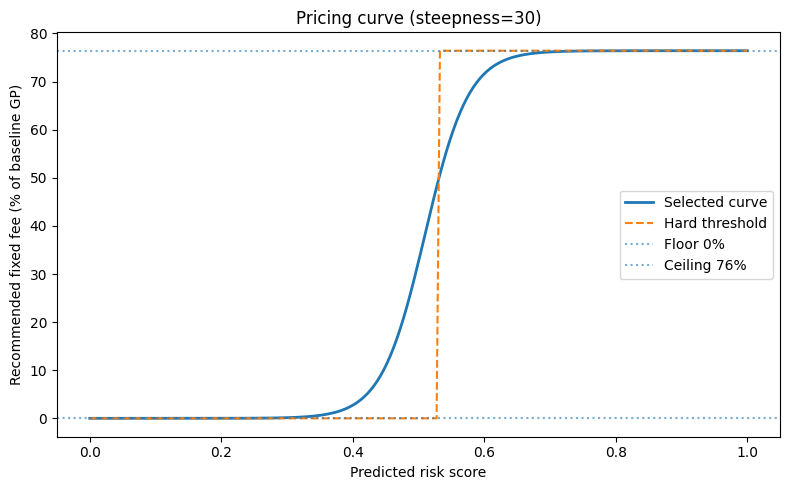

In [7]:
def make_logistic_curve(midpoint, steepness):
    def curve(risk):
        risk = np.asarray(risk)
        s = 1 / (1 + np.exp(-steepness * (risk - midpoint)))
        return FEE_FLOOR + (FEE_CEILING - FEE_FLOOR) * s
    return curve


def make_hard_threshold_curve(midpoint):
    def curve(risk):
        risk = np.asarray(risk)
        return np.where(risk < midpoint, FEE_FLOOR, FEE_CEILING)
    return curve


def prep_backtest_frame(frame):
    f = frame.copy()
    f = f[f["commission_forward_12m"].notna()].copy()
    f["baseline_commission"] = f["commission_l12m"]
    f["baseline_gp"] = f["core_gp_l12m"]
    f["baseline_fixed_eur"] = f["fixed_fee_share_mean_l12m"] * f["baseline_gp"]
    f["baseline_variable_rate"] = (
        (f["baseline_gp"] - f["baseline_fixed_eur"]) / f["baseline_commission"]
    ).clip(lower=0)
    return f


def apply_fee_curve(frame, fee_curve_fn):
    f = frame.copy()
    f["new_fixed_pct_of_gp"] = np.clip(fee_curve_fn(f["risk_score"].values), 0, 1)
    f["new_fixed_eur"] = f["new_fixed_pct_of_gp"] * f["baseline_gp"]
    f["new_variable_rate"] = (
        (f["baseline_gp"] - f["new_fixed_eur"]) / f["baseline_commission"]
    ).clip(lower=0)

    fwd = f["commission_forward_12m"]
    f["old_gp_forward"] = f["baseline_fixed_eur"] + f["baseline_variable_rate"] * fwd
    f["new_gp_forward"] = f["new_fixed_eur"] + f["new_variable_rate"] * fwd
    f["gp_delta_new_vs_old"] = f["new_gp_forward"] - f["old_gp_forward"]

    f["actual_direction"] = np.where(
        fwd < f["baseline_commission"] * 0.9,
        "decline",
        np.where(fwd > f["baseline_commission"], "growth", "flat")
    )
    return f


def gp_delta_pct(f):
    return f["gp_delta_new_vs_old"].sum() / f["old_gp_forward"].sum() * 100


SATURATION_TOL = 0.02

def saturation_share(fee_curve_fn, risk_scores, tol=SATURATION_TOL):
    fee = np.clip(fee_curve_fn(risk_scores), 0, 1)
    saturated = (fee <= FEE_FLOOR + tol) | (fee >= FEE_CEILING - tol)
    return saturated.mean() * 100


train_bt_base = prep_backtest_frame(train_df)
train_risk_scores = train_bt_base["risk_score"].values


# Quantile-step reference
train_quintile_cuts = train_df["risk_score"].quantile([0.2, 0.4, 0.6, 0.8]).values
tier_fees = np.linspace(FEE_FLOOR, FEE_CEILING, 5)

def curve_quantile_step(risk):
    risk = np.atleast_1d(risk)
    tier_idx = np.searchsorted(train_quintile_cuts, risk, side="right")
    return tier_fees[tier_idx]

D_SATURATION_PCT = saturation_share(curve_quantile_step, train_risk_scores)
print(f"Concentration cap: {D_SATURATION_PCT:.1f}%")


midpoints = np.arange(0.40, 0.66, 0.01)
steepness_values = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000]


# Unconstrained logistic search
grid_results = []
best_score, best_params = -np.inf, None

for midpoint in midpoints:
    for steepness in steepness_values:
        candidate = make_logistic_curve(midpoint, steepness)
        score = gp_delta_pct(apply_fee_curve(train_bt_base, candidate))
        sat_pct = saturation_share(candidate, train_risk_scores)

        grid_results.append({
            "midpoint": float(midpoint),
            "steepness": steepness,
            "gp_delta_pct": score,
            "saturation_pct": sat_pct
        })

        if score > best_score:
            best_score, best_params = score, (midpoint, steepness)

grid_results_df = pd.DataFrame(grid_results)

print(
    f"Best unconstrained: midpoint={best_params[0]:.2f}, "
    f"steepness={best_params[1]}, GP={best_score:+.3f}%"
)


# Hard threshold
best_threshold_score, best_threshold_midpoint = -np.inf, None

for midpoint in midpoints:
    threshold_curve = make_hard_threshold_curve(midpoint)
    score = gp_delta_pct(apply_fee_curve(train_bt_base, threshold_curve))

    if score > best_threshold_score:
        best_threshold_score, best_threshold_midpoint = score, midpoint

print(
    f"Hard threshold: midpoint={best_threshold_midpoint:.2f}, "
    f"GP={best_threshold_score:+.3f}%"
)


# Apply concentration constraint
eligible = grid_results_df[
    grid_results_df["saturation_pct"] <= D_SATURATION_PCT
]

selected_row = eligible.loc[eligible["gp_delta_pct"].idxmax()]
best_params = (float(selected_row["midpoint"]), int(selected_row["steepness"]))
best_score = float(selected_row["gp_delta_pct"])
selected_saturation = float(selected_row["saturation_pct"])

print(
    f"Selected curve: midpoint={best_params[0]:.2f}, "
    f"steepness={best_params[1]}"
)
print(f"Training GP uplift: {best_score:+.3f}%")
print(f"Concentration: {selected_saturation:.1f}%")


fee_pct_of_gp = make_logistic_curve(*best_params)
holdout_df["new_fixed_pct_of_gp"] = fee_pct_of_gp(holdout_df["risk_score"].values)


fig, ax = plt.subplots(figsize=(8, 5))
risk_grid = np.linspace(0, 1, 200)

ax.plot(risk_grid, fee_pct_of_gp(risk_grid) * 100, linewidth=2, label="Selected curve")
ax.plot(
    risk_grid,
    make_hard_threshold_curve(best_threshold_midpoint)(risk_grid) * 100,
    linewidth=1.5,
    linestyle="--",
    label="Hard threshold"
)

ax.axhline(FEE_FLOOR * 100, linestyle=":", alpha=0.6, label=f"Floor {FEE_FLOOR:.0%}")
ax.axhline(FEE_CEILING * 100, linestyle=":", alpha=0.6, label=f"Ceiling {FEE_CEILING:.0%}")
ax.set_xlabel("Predicted risk score")
ax.set_ylabel("Recommended fixed fee (% of baseline GP)")
ax.set_title(f"Pricing curve (steepness={best_params[1]})")
ax.legend()

fig.tight_layout()
fig.savefig(OUT_DIR / "fee_curve.png", dpi=150)
plt.show()

## 7. Backtest
Historical and repriced terms are both applied to realised forward commission. The repriced terms are ETR-neutral at baseline commission, which is checked directly below.

A fully variable comparator is also included to show whether the risk-based fixed/variable split adds value beyond simply removing fixed fees.

In [8]:
t = apply_fee_curve(prep_backtest_frame(holdout_df), fee_pct_of_gp)

gp_check = t["new_fixed_eur"] + t["new_variable_rate"] * t["baseline_commission"]
max_gp_drift = (gp_check - t["baseline_gp"]).abs().max()
status = "PASS" if max_gp_drift < 1.0 else "FAIL"
print(f"ETR-neutrality check: €{max_gp_drift:,.4f} ({status})")

t["variable_only_rate"] = t["baseline_gp"] / t["baseline_commission"]
t["fully_variable_gp_forward"] = t["variable_only_rate"] * t["commission_forward_12m"]
t["gp_delta_var_vs_old"] = t["fully_variable_gp_forward"] - t["old_gp_forward"]

print("====BACKTEST====")
print(f"Total old-terms GP :          €{t['old_gp_forward'].sum():,.0f}")
print(f"Total new-terms GP :          €{t['new_gp_forward'].sum():,.0f}")
print(f"Total fully-variable GP:     €{t['fully_variable_gp_forward'].sum():,.0f}")
print(f"\nNew vs old, total GP delta:            €{t['gp_delta_new_vs_old'].sum():+,.0f} "
      f"({gp_delta_pct(t):+.2f}% of old-terms GP)")
print(f"Fully-variable vs old, total GP delta: €{t['gp_delta_var_vs_old'].sum():+,.0f} "
      f"({t['gp_delta_var_vs_old'].sum() / t['old_gp_forward'].sum() * 100:+.2f}% of old-terms GP)")

ETR-neutrality check: €0.0000 (PASS)
====BACKTEST====
Total old-terms GP :          €39,175,587
Total new-terms GP :          €40,670,553
Total fully-variable GP:     €39,689,411

New vs old, total GP delta:            €+1,494,966 (+3.82% of old-terms GP)
Fully-variable vs old, total GP delta: €+513,824 (+1.31% of old-terms GP)


## 8. Mirror scenario by direction

The population is split by actual realised direction, showing the protection gained on clients that declined against the cost incurred on clients that grew.

In [9]:
print("====MIRROR SCENARIO - GP delta by ACTUAL realised outcome====")
mirror = t.groupby("actual_direction").agg(
    n=("gp_delta_new_vs_old", "count"),
    total_old_gp=("old_gp_forward", "sum"),
    total_new_gp=("new_gp_forward", "sum"),
    gp_delta=("gp_delta_new_vs_old", "sum"),
).reset_index()
mirror["gp_delta_pct_of_old"] = mirror["gp_delta"] / mirror["total_old_gp"] * 100
print(mirror.round(2).to_string(index=False))
mirror.to_csv(OUT_DIR / "mirror_scenario_by_actual_direction.csv", index=False)

====MIRROR SCENARIO - GP delta by ACTUAL realised outcome====
actual_direction    n  total_old_gp  total_new_gp   gp_delta  gp_delta_pct_of_old
         decline 1615   11660865.52   13630991.45 1970125.93                16.90
            flat  183    4815655.25    4818416.93    2761.68                 0.06
          growth 1376   22699066.35   22221144.65 -477921.71                -2.11


## 9. Backtest by risk band

The backtest results broken down by risk band.

====BACKTEST BY RISK BAND====
risk_band   n  actual_decline_rate  total_old_gp  total_new_gp   gp_delta  mean_new_fixed_pct  gp_delta_pct_of_old
   20-30% 110                0.300   2258399.565   2386111.589 127712.024               0.001                5.655
   30-40% 571                0.338  12637614.994  12798356.957 160741.963               0.011                1.272
   40-50% 913                0.428  14851093.799  14952584.735 101490.936               0.129                0.683
   50-60% 726                0.573   6214812.096   6196470.126 -18341.970               0.559               -0.295
   60-70% 621                0.646   2563806.226   3272127.795 708321.569               0.748               27.628
   70-80% 228                0.772    646014.775   1052016.223 406001.448               0.763               62.847
   80-90%   5                1.000      3845.665     12885.600   9039.935               0.764              235.068


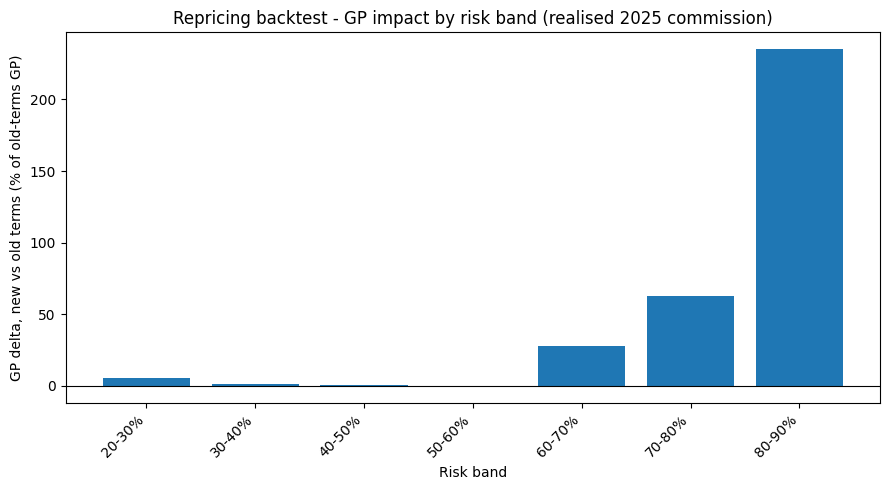

In [10]:
t["risk_band"] = pd.cut(t["risk_score"], bins=np.arange(0, 1.01, 0.10),
                        labels=[f"{b}-{b+10}%" for b in range(0, 100, 10)],
                        include_lowest=True)

by_band = t.groupby("risk_band", observed=True).agg(
    n=("gp_delta_new_vs_old", "count"),
    actual_decline_rate=("actual_direction", lambda x: (x == "decline").mean()),
    total_old_gp=("old_gp_forward", "sum"),
    total_new_gp=("new_gp_forward", "sum"),
    gp_delta=("gp_delta_new_vs_old", "sum"),
    mean_new_fixed_pct=("new_fixed_pct_of_gp", "mean"),
).reset_index()
by_band["gp_delta_pct_of_old"] = by_band["gp_delta"] / by_band["total_old_gp"] * 100

print("====BACKTEST BY RISK BAND====")
print(by_band.round(3).to_string(index=False))
by_band.to_csv(OUT_DIR / "backtest_by_risk_band.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(by_band["risk_band"].astype(str), by_band["gp_delta_pct_of_old"])
ax.axhline(color="black", linewidth=0.8)
ax.set_xlabel("Risk band")
ax.set_ylabel("GP delta, new vs old terms (% of old-terms GP)")
ax.set_title("Repricing backtest - GP impact by risk band (realised 2025 commission)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(OUT_DIR / "backtest_gp_delta_by_band.png", dpi=150)
plt.show()



## 10. Materiality as a share of client spend

To give the GP movement a client-level scale, I express the absolute GP delta as a percentage of trailing commission paid to publishers.

Clients with less than €500 trailing commission are excluded from this percentile diagnostic because very small denominators produce extreme percentages. They remain in the main backtest and GP totals.


Materiality
Excluded from percentile calculation: 547 / 3,174 (17.2%)
Median client spend: €7,884
Median |GP delta| / spend: 2.29%
P90 |GP delta| / spend: 15.25%
P99 |GP delta| / spend: 109.56%


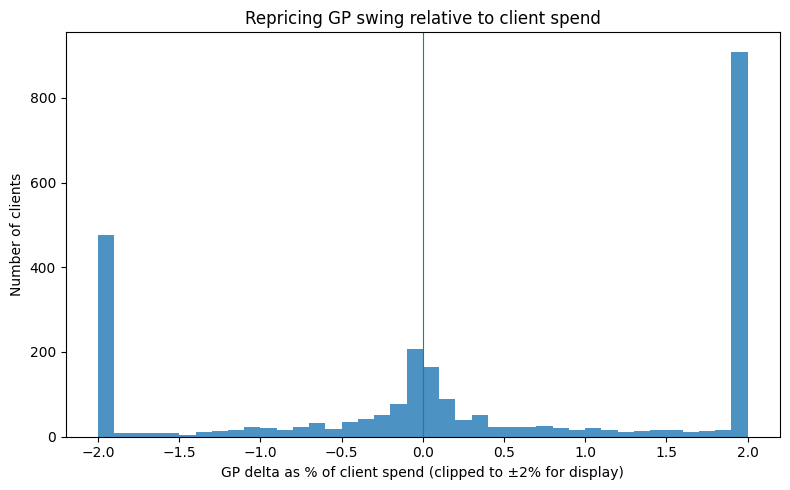

In [11]:
MIN_COMMISSION_FOR_MATERIALITY = 500

t["gp_delta_pct_of_spend"] = (
    t["gp_delta_new_vs_old"] / t["commission_l12m"]
) * 100

n_below_floor = (
    t["commission_l12m"] < MIN_COMMISSION_FOR_MATERIALITY
).sum()

t_materiality = t[
    t["commission_l12m"] >= MIN_COMMISSION_FOR_MATERIALITY
].copy()

print("\nMateriality")

print(
    f"Excluded from percentile calculation: "
    f"{n_below_floor:,} / {len(t):,} "
    f"({n_below_floor / len(t):.1%})"
)

median_spend = t_materiality["commission_l12m"].median()
median_pct = t_materiality["gp_delta_pct_of_spend"].abs().median()
p90_pct = t_materiality["gp_delta_pct_of_spend"].abs().quantile(0.90)
p99_pct = t_materiality["gp_delta_pct_of_spend"].abs().quantile(0.99)

print(f"Median client spend: €{median_spend:,.0f}")
print(f"Median |GP delta| / spend: {median_pct:.2f}%")
print(f"P90 |GP delta| / spend: {p90_pct:.2f}%")
print(f"P99 |GP delta| / spend: {p99_pct:.2f}%")


fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    t_materiality["gp_delta_pct_of_spend"].clip(-2, 2),
    bins=40,
    alpha=0.8
)

ax.axvline(0, linewidth=0.8)
ax.set_xlabel("GP delta as % of client spend (clipped to ±2% for display)")
ax.set_ylabel("Number of clients")
ax.set_title("Repricing GP swing relative to client spend")

fig.tight_layout()
fig.savefig(OUT_DIR / "materiality_histogram.png", dpi=150)
plt.show()